In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.head()
df.shape

(1000, 3)

Text(0, 0.5, "['Placement exam marks']")

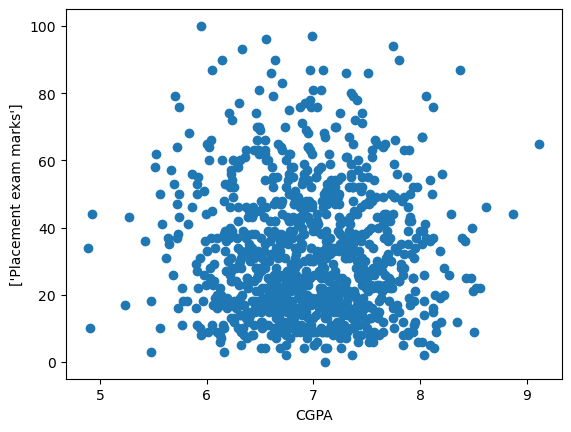

In [4]:
plt.scatter(df['cgpa'], df['placement_exam_marks'])
plt.xlabel('CGPA')
plt.ylabel(['Placement exam marks'])

In [5]:
X = df.iloc[:, 0:1]
y = df.iloc[:, -1]

In [6]:
y

0      1
1      1
2      1
3      1
4      0
      ..
995    1
996    1
997    0
998    1
999    1
Name: placed, Length: 1000, dtype: int64

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [8]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

Text(0, 0.5, 'Placement exam marks')

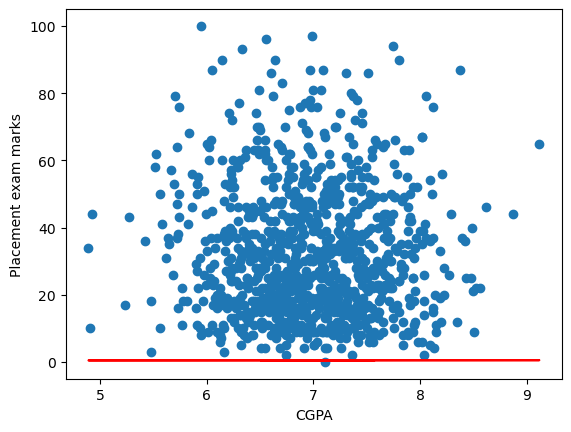

In [9]:
plt.scatter(df['cgpa'], df['placement_exam_marks'])
plt.plot(X_train, lr.predict(X_train), color='red')
plt.xlabel('CGPA')
plt.ylabel('Placement exam marks')

In [10]:
# Make predictions on the unseen test data and retrieve the true target values for comparison
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = lr.predict(X_test)
y_test.values

array([1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 1])

In [11]:
print("MAE", mean_absolute_error(y_test, y_pred))

MAE 0.5006607813375833


In [12]:
print("MSE", mean_squared_error(y_test, y_pred))

MSE 0.2512374456800925


In [13]:
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))

RMSE 0.5012359181863292


In [15]:
print("R2 Score", r2_score(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

R2 Score -0.008580673143687712


In [16]:
# Adjusted R2 Score
X_test.shape

(200, 1)

In [17]:
1 - ((1-r2) * (40-1)/(40-1-1))

-0.035122269805363704

In [19]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(len(new_df1))

new_df1 = new_df1[['cgpa', 'random_feature', 'placement_exam_marks']]
new_df1.head()

,cgpa,random_feature,placement_exam_marks
0,7.19,0.087460,26.0
1,7.46,0.831687,38.0
2,7.54,0.113847,40.0
3,6.42,0.458954,8.0
4,7.23,0.903204,17.0


Text(0, 0.5, 'placement_exam_marks')

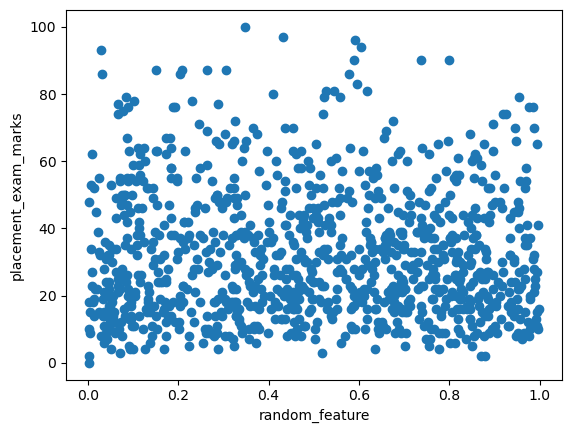

In [20]:
plt.scatter(new_df1['random_feature'], new_df1['placement_exam_marks'])
plt.xlabel('random_feature')
plt.ylabel('placement_exam_marks')

In [21]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [23]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [24]:
y_pred = lr.predict(X_test)

In [25]:
print("R2 score", r2_score(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

R2 score -0.008751987318797116


In [26]:
1 - ((1-r2)*(40-1)/(40-1-2))

-0.06327912176846184

In [28]:
new_df2 = df.copy()
new_df2['iq'] = new_df2['placement_exam_marks'] + (np.random.randint(-12,12,len(new_df2))/10)
new_df2 = new_df2[['cgpa', 'iq', 'placement_exam_marks']]

In [29]:
new_df2.sample(5)

,cgpa,iq,placement_exam_marks
819,6.93,9.9,10.0
294,6.12,17.9,17.0
280,6.62,56.0,55.0
781,7.17,49.9,49.0
532,6.90,20.3,20.0


Text(0, 0.5, 'Placement_exam_marks')

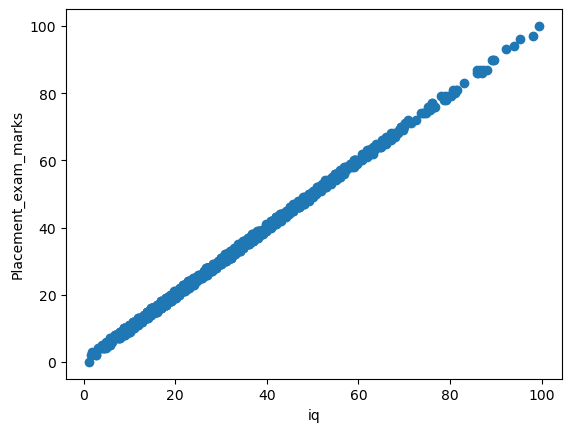

In [30]:
plt.scatter(new_df2['iq'], new_df2['placement_exam_marks'])
plt.xlabel('iq')
plt.ylabel('Placement_exam_marks')

In [31]:
np.random.randint(-100,100)

27

In [32]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [34]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [35]:
print("R2 score", r2_score(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

R2 score 0.9986007880093293


In [36]:
1 - ((1-r2) * (40-1)/(40-1-2))

0.9985251549287525